In [ ]:
!pip install -q transformers datasets scikit-learn seaborn matplotlib accelerate


In [ ]:
import os, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import Dataset, DatasetDict
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
)
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
import pandas as pd
file_path = '/content/drive/MyDrive/project /Data20categories.txt'
try:
    df_categories = pd.read_csv(file_path)
    print("File loaded successfully into DataFrame 'df_categories'.")
    print("First 5 rows of the DataFrame:")
    display(df_categories.head())
except Exception as e:
    print(f"Error loading file: {e}")
    print("If it's not a CSV, you might need to specify a different delimiter or use pd.read_table, or another function appropriate for your file type.")

Error loading file: [Errno 2] No such file or directory: '/content/drive/MyDrive/project /Data20categories.txt'
If it's not a CSV, you might need to specify a different delimiter or use pd.read_table, or another function appropriate for your file type.


In [ ]:
MODEL_NAME   = "distilbert-base-uncased"
OUTPUT_DIR   = "./distilbert_output"
MAX_LENGTH   = 64
BATCH_SIZE   = 32
EPOCHS       = 6
LR           = 2e-5
WEIGHT_DECAY = 0.01
SEED         = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)


In [ ]:
from google.colab import files
uploaded = files.upload()
print("Uploaded files:", list(uploaded.keys()))


TypeError: 'NoneType' object is not subscriptable

In [ ]:
DATA_PATH = '/content/Data20categories.txt'

In [ ]:

def load_and_preprocess(path):
    df = pd.read_csv(path)

    def build_text(row):
        parts = [str(row["name"])]

        flavor = str(row.get("Flavor", "")).strip()
        if flavor and flavor.lower() not in ("nan", "other", ""):
            parts.append(flavor)

        brand = str(row.get("Brand Name", "")).strip()
        if brand and brand.lower() not in ("nan", "other", "generic", ""):
            parts.append(brand)

        flags = {
            "organic":    row.get("is_organic", 0),
            "sugar-free": row.get("is_sugar_free", 0),
            "vegan":      row.get("is_vegan", 0),
            "keto":       row.get("is_keto", 0),
        }
        active = [k for k, v in flags.items() if v == 1]
        if active:
            parts.append(" ".join(active))

        return " | ".join(parts)

    df["text"]      = df.apply(build_text, axis=1)
    df["label_str"] = df["keyword"].str.strip().str.lower()

    le = LabelEncoder()
    df["label"] = le.fit_transform(df["label_str"])

    print(f"Loaded {len(df):,} samples | {len(le.classes_)} categories")
    print("Categories:", list(le.classes_))
    return df[["text", "label", "label_str"]], le


df, le = load_and_preprocess(DATA_PATH)
df.head(3)


In [ ]:

train_df, val_df = train_test_split(
    df, test_size=0.15, random_state=SEED, stratify=df["label"]
)
print(f"Train: {len(train_df):,}  |  Val: {len(val_df):,}")

tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
    )

train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df.reset_index(drop=True))
hf_data  = DatasetDict({"train": train_ds, "validation": val_ds})
hf_data  = hf_data.map(tokenize_fn, batched=True)
hf_data.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

print(hf_data)


In [ ]:
num_labels = len(le.classes_)
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=num_labels
)
model.config.id2label = {i: c for i, c in enumerate(le.classes_)}
model.config.label2id = {c: i for i, c in enumerate(le.classes_)}

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f" |  Total params: {total_params/1e6:.1f}M  |  Trainable: {trainable/1e6:.1f}M")


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds)}

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch", # Changed from evaluation_strategy to eval_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,

    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,

    learning_rate=LR,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",

    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,

    logging_dir=f"{OUTPUT_DIR}/logs",
    logging_steps=20,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=hf_data["train"],
    eval_dataset=hf_data["validation"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

In [ ]:
train_result = trainer.train()
print(f"   Final train loss : {train_result.training_loss:.4f}")


In [ ]:
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
np.save(f"{OUTPUT_DIR}/label_classes.npy", le.classes_)
print(f"Model saved to '{OUTPUT_DIR}/'")


In [ ]:

val_tok = Dataset.from_pandas(val_df.reset_index(drop=True))
val_tok = val_tok.map(tokenize_fn, batched=True)
val_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

preds_out = trainer.predict(val_tok)
y_pred    = np.argmax(preds_out.predictions, axis=-1)
y_true    = preds_out.label_ids

acc = accuracy_score(y_true, y_pred)
print(f" validation Accuracy : {acc * 100:.2f}%")

In [ ]:
print(classification_report(y_true, y_pred, target_names=list(le.classes_)))

In [ ]:
cm  = confusion_matrix(y_true, y_pred)
class_names = list(le.classes_)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.4,
    ax=ax,
)
ax.set_title("Confusion Matrix — Validation Set", fontsize=15, pad=12)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label",      fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=150)
plt.show()


In [ ]:
log_history = trainer.state.log_history
train_logs  = [e for e in log_history if "loss"      in e and "eval_loss" not in e]
eval_logs   = [e for e in log_history if "eval_loss" in e]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if train_logs:
    axes[0].plot(
        [e["step"] for e in train_logs],
        [e["loss"] for e in train_logs],
        color="steelblue", linewidth=1.8, label="Train Loss"
    )
if eval_logs:
    axes[0].plot(
        [e["step"]      for e in eval_logs],
        [e["eval_loss"] for e in eval_logs],
        color="tomato", linewidth=2, marker="o", label="Val Loss"
    )
axes[0].set_title("Training & Validation Loss", fontsize=13)
axes[0].set_xlabel("Step"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

if eval_logs and "eval_accuracy" in eval_logs[0]:
    axes[1].plot(
        [e["step"]          for e in eval_logs],
        [e["eval_accuracy"] for e in eval_logs],
        color="seagreen", linewidth=2, marker="s", label="Val Accuracy"
    )
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title("Validation Accuracy per Epoch", fontsize=13)
    axes[1].set_xlabel("Step"); axes[1].set_ylabel("Accuracy")
    axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150)
plt.show()


In [ ]:
def recommend_category(user_query, top_k=3):

    inputs = tokenizer(
        user_query,
        return_tensors="pt",
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
    ).to(DEVICE)

    model.eval()
    model.to(DEVICE)

    with torch.no_grad():
        logits = model(**inputs).logits

    probs       = torch.softmax(logits, dim=-1).squeeze().cpu().numpy()
    top_indices = np.argsort(probs)[::-1][:top_k]

    return {
        "query"        : user_query,
        "top_category" : le.classes_[top_indices[0]],
        "confidence"   : float(probs[top_indices[0]]),
        "top_k_results": [
            {"category": le.classes_[i], "confidence": round(float(probs[i]), 4)}
            for i in top_indices
        ],
    }


In [ ]:
demo_queries = [
    "I need a vegan soy milk substitute",
    "looking for dark chocolate with nuts",
    "best olive oil for cooking",
    "low sugar strawberry jam",
    "protein-rich Greek yogurt",
    "gluten-free pasta for a diet meal",
    "spicy tomato sauce for pizza",
    "organic honey for tea",
]

print("Chatbot Recommendation Demo")
for q in demo_queries:
    res = recommend_category(q, top_k=3)
    top3 = " | ".join(
        f"{r['category']} ({r['confidence']*100:.1f}%)"
        for r in res["top_k_results"]
    )
    print(f"\nQuery : {res['query']}")
    print(f"  → {res['top_category'].upper()}  ({res['confidence']*100:.1f}%)")
    print(f"  Top-3 : {top3}")


In [ ]:
your_query = "I want something sweet and crunchy for breakfast"   # ← change this!
result = recommend_category(your_query, top_k=5)
print(f"Query      : {result['query']}")
print(f"Best Match : {result['top_category'].upper()}  ({result['confidence']*100:.1f}% confidence)\n")
print("Top-5 Predictions:")
for i, r in enumerate(result["top_k_results"], 1):
    bar = "" * int(r["confidence"] * 40)
    print(f"  {i}. {r['category']:<12} {r['confidence']*100:5.1f}%  {bar}")


In [ ]:
# Test multiple queries at once
test_queries = [
    "cheap full cream milk",
    "vegan chocolate bar",
    "gluten free pasta",
    "sugar free biscuits",
    "olive oil for salad",
]

for q in test_queries:
    r = recommend_category(q, top_k=3)
    print(f"\n'{q}'")
    print(f"   → {r['top_category'].upper()} ({r['confidence']*100:.1f}%)")

In [ ]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
import numpy as np, torch

OUTPUT_DIR = "./distilbert_output"
MAX_LENGTH = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer     = DistilBertTokenizer.from_pretrained(OUTPUT_DIR)
model         = DistilBertForSequenceClassification.from_pretrained(OUTPUT_DIR)
label_classes = np.load(f"{OUTPUT_DIR}/label_classes.npy", allow_pickle=True)
model.eval().to(DEVICE)

def recommend_category(user_query, top_k=3):
    inputs = tokenizer(
        user_query, return_tensors="pt",
        padding="max_length", truncation=True, max_length=MAX_LENGTH
    ).to(DEVICE)
    with torch.no_grad():
        logits = model(**inputs).logits
    probs       = torch.softmax(logits, dim=-1).squeeze().cpu().numpy()
    top_indices = np.argsort(probs)[::-1][:top_k]
    return {
        "top_category" : label_classes[top_indices[0]],
        "confidence"   : float(probs[top_indices[0]]),
        "top_k_results": [
            {"category": label_classes[i], "confidence": round(float(probs[i]), 4)}
            for i in top_indices
        ]
    }

# Test it
result = recommend_category("I need fresh orange juice", top_k=3)
print(result)

In [ ]:
custom_tests = [
    # (your_text,          expected_category)
    ("full cream almarai milk 1kg",          "milk"),
    ("dark chocolate with hazelnuts 100g",   "chocolate"),
    ("extra virgin olive oil 750ml",         "oil"),
    ("basmati rice 5kg pack",                "rice"),
    ("strawberry jam low sugar",             "jam"),
    ("penne pasta 500g",                     "pasta"),
    ("hand wash soap antibacterial",         "soap"),
    ("cheddar cheese slices 200g",           "cheese"),
    ("salted roasted cashews 250g",          "nuts"),
    ("plain greek yogurt 200g",              "yogurt"),
]

correct = 0
print(f"{'Query':<45} {'Expected':<12} {'Predicted':<12} {'Conf%':<8} {'✓/✗'}")
print("─" * 90)

for text, expected in custom_tests:
    res  = recommend_category(text, top_k=1)
    pred = res["top_category"]
    conf = res["confidence"] * 100
    ok   =  "done "if pred == expected else "nan"
    if pred == expected:
        correct += 1
    print(f"{text:<45} {expected:<12} {pred:<12} {conf:<8.1f} {ok}")

print(f"\nManual Test Accuracy: {correct}/{len(custom_tests)} = {correct/len(custom_tests)*100:.1f}%")

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

all_texts  = df["text"].tolist()
all_labels = df["label_str"].tolist()

predictions = []
BATCH = 64

for i in range(0, len(all_texts), BATCH):
    batch = all_texts[i : i + BATCH]
    inputs = tokenizer(
        batch, return_tensors="pt",
        padding="max_length", truncation=True, max_length=MAX_LENGTH
    ).to(DEVICE)
    with torch.no_grad():
        logits = model(**inputs).logits
    preds = torch.argmax(logits, dim=-1).cpu().numpy()
    predictions.extend([le.classes_[p] for p in preds])
    if i % 500 == 0:
        print(f"  Processed {i}/{len(all_texts)}...")

acc = accuracy_score(all_labels, predictions)
print(f"\n Full Dataset Accuracy: {acc*100:.2f}%")
print(classification_report(all_labels, predictions))

In [ ]:
from collections import defaultdict

category_correct = defaultdict(int)
category_total   = defaultdict(int)

for true, pred in zip(all_labels, predictions):
    category_total[true]   += 1
    if true == pred:
        category_correct[true] += 1

categories = sorted(category_total.keys())
accuracies = [category_correct[c] / category_total[c] * 100 for c in categories]


fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(categories, accuracies, color=[
    "seagreen" if a >= 90 else "steelblue" if a >= 75 else "tomato"
    for a in accuracies
])
ax.axhline(y=np.mean(accuracies), color="black", linestyle="--",
           linewidth=1.5, label=f"Mean: {np.mean(accuracies):.1f}%")
ax.set_ylim(0, 110)
ax.set_title("Per-Category Accuracy", fontsize=14)
ax.set_xlabel("Category"); ax.set_ylabel("Accuracy (%)")
ax.legend()

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1.5,
            f"{acc:.0f}%", ha="center", fontsize=8)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#ResNet-50

### Step 1 — Mount Google Drive & Verify GPU

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf

print('='*50)
print('TensorFlow version :', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU detected       : {gpus[0].name}')
else:
    print('No GPU detected — go to Runtime > Change runtime type > T4 GPU')
print('='*50)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow version : 2.20.0
GPU detected       : /physical_device:GPU:0


### Step 2 — Import All Libraries

In [ ]:
!pip install -q scikit-learn matplotlib seaborn tqdm opencv-python-headless

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import load_img, img_to_array

from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder

# Consistent plot style
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f8f9fa',
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'font.size'        : 10,
})

print('All libraries imported successfully')

All libraries imported successfully


### Step 3 — Configuration

### Step 3.1 — Upload Dataset (for local/Kaggle environments)

If you're running this notebook outside of a Google Drive-mounted Colab instance (e.g., on Kaggle or a local machine), you'll need to upload your dataset directly. Please compress your `resized_dataset` folder into a `.zip` file and upload it below. It will be unzipped into the `/content/` directory.

**Note:** If you are using Google Drive and your `DATASET_DIR` is already correctly configured to your Drive path, you can skip these two cells.

In [ ]:
from google.colab import files
import zipfile

# --- Upload the zipped dataset ---
print("Please upload your 'resized_dataset.zip' file.")
uploaded = files.upload()

if 'resized_dataset.zip' in uploaded:
    zip_path = '/content/resized_dataset.zip'
    with open(zip_path, 'wb') as f:
        f.write(uploaded['resized_dataset.zip'])
    print("File uploaded successfully. Unzipping...")

    # --- Unzip the dataset ---
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/')
    print("Dataset unzipped to '/content/resized_dataset/'")

    # --- Verify the unzipped directory (optional) ---
    if os.path.exists('/content/resized_dataset'):
        print("Unzipped directory found.")
    else:
        # Sometimes zip files extract into a subdirectory, adjust if needed
        extracted_name = os.listdir('/content/')[0] # Get first item in /content
        if os.path.isdir(os.path.join('/content', extracted_name)): # If it's a directory
            print(f"Dataset unzipped to /content/{extracted_name}. Renaming to resized_dataset...")
            os.rename(os.path.join('/content', extracted_name), '/content/resized_dataset')

    # --- Clean up the zip file ---
    os.remove(zip_path)
    print("Original zip file removed.")
else:
    print("No 'resized_dataset.zip' found. Please ensure you upload the correct file.")


Please upload your 'resized_dataset.zip' file.


KeyboardInterrupt: 

In [ ]:

DATASET_DIR = '/content/drive/MyDrive/Deep_Learning/resized_dataset'
OUTPUT_DIR  = '/content/drive/MyDrive/Deep_Learning/features_output'


IMAGE_SIZE  = 224
BATCH_SIZE  = 32
FREEZE_ALL  = True     # True = freeze all | False = unfreeze last block

VALID_EXTS  = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Configuration')
print(f'  Dataset   : {DATASET_DIR}')
print(f'  Output    : {OUTPUT_DIR}')
print(f'  Image size: {IMAGE_SIZE}x{IMAGE_SIZE}')
print(f'  Batch size: {BATCH_SIZE}')
print(f'  Freeze all: {FREEZE_ALL}')

#### configuration on FREEZE ALL False

In [ ]:

DATASET_DIR = '/content/drive/MyDrive/Deep_Learning/resized_dataset'
OUTPUT_DIR  = '/content/drive/MyDrive/Deep_Learning/features_output'


IMAGE_SIZE  = 256
BATCH_SIZE  = 32
FREEZE_ALL  = False     # True = freeze all | False = unfreeze last block


VALID_EXTS  = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Configuration')
print(f'  Dataset   : {DATASET_DIR}')
print(f'  Output    : {OUTPUT_DIR}')
print(f'  Image size: {IMAGE_SIZE}x{IMAGE_SIZE}')
print(f'  Batch size: {BATCH_SIZE}')
print(f'  Freeze all: {FREEZE_ALL}')

Configuration
  Dataset   : /content/drive/MyDrive/Deep_Learning/resized_dataset
  Output    : /content/drive/MyDrive/Deep_Learning/features_output
  Image size: 256x256
  Batch size: 32
  Freeze all: False


### Step 4 — Scan Dataset

In [ ]:
def scan_dataset(dataset_dir, valid_exts):
    """
    Walk through dataset_dir.
    Each sub-folder = one class.
    Returns:
        image_paths : list of str
        labels      : list of str  (class name)
    """
    image_paths = []
    labels      = []
    dataset_dir = Path(dataset_dir)

    if not dataset_dir.exists():
        raise FileNotFoundError(
            f'Dataset not found: {dataset_dir}\n'
            'Check that Drive is mounted and the path is correct.'
        )

    for class_dir in sorted(dataset_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        for img_file in sorted(class_dir.iterdir()):
            if img_file.suffix.lower() in valid_exts:
                image_paths.append(str(img_file))
                labels.append(class_dir.name)

    return image_paths, labels


image_paths, labels = scan_dataset(DATASET_DIR, VALID_EXTS)

# Encode labels to integers
le          = LabelEncoder()
labels_int  = le.fit_transform(labels)
class_names = le.classes_
n_classes   = len(class_names)

print(f'Total images : {len(image_paths)}')
print(f'Total classes: {n_classes}')
print()
print(f'{"Class":<20} {"Count":>6}')
print('-' * 28)
for cls in class_names:
    cnt = labels.count(cls)
    print(f'{cls:<20} {cnt:>6}')

Total images : 3693
Total classes: 20

Class                 Count
----------------------------
biscuits                 53
bread                    78
butter                   93
cheese                  138
chips                   242
chocolate               317
flour                   162
honey                   230
jam                     293
juice                   305
milk                    207
nuts                    203
oil                     150
pasta                   218
rice                    215
sauce                   227
soap                     59
spices                  247
sugar                   174
yogurt                   82


### Step 5 — Image Quality Check
We check three things for every image:


*   Can it be opened? (no corrupt files)
*   Is the size correct? (already resized?)
*   Is it RGB? (not grayscale or RGBA)

> Any image that fails these checks is flagged — we skip it during feature extraction.


In [ ]:
def check_image_quality(image_paths, expected_size=None):
    """
    For each image path:
      - Try to open it
      - Check width, height, channels
      - Record any issues

    Returns:
        report  : list of dicts
        bad_idx : list of indices with problems
    """
    report  = []
    bad_idx = []

    widths, heights, channels_list = [], [], []

    for i, path in enumerate(tqdm(image_paths, desc='Quality check')):
        row = {'path': path, 'status': 'ok', 'issue': '', 'w': 0, 'h': 0, 'c': 0}
        try:
            img = cv2.imread(path)
            if img is None:
                raise ValueError('Cannot read file')

            h, w = img.shape[:2]
            c    = img.shape[2] if img.ndim == 3 else 1
            row.update({'w': w, 'h': h, 'c': c})
            widths.append(w)
            heights.append(h)
            channels_list.append(c)

            issues = []
            if expected_size and (w != expected_size or h != expected_size):
                issues.append(f'size={w}x{h} (expected {expected_size}x{expected_size})')
            if c != 3:
                issues.append(f'channels={c} (expected 3)')

            if issues:
                row['status'] = 'warning'
                row['issue']  = ' | '.join(issues)
                bad_idx.append(i)

        except Exception as e:
            row['status'] = 'error'
            row['issue']  = str(e)
            bad_idx.append(i)

        report.append(row)

    df = pd.DataFrame(report)
    return df, bad_idx, widths, heights


quality_df, bad_idx, widths, heights = check_image_quality(image_paths)

n_ok      = (quality_df['status'] == 'ok').sum()
n_warn    = (quality_df['status'] == 'warning').sum()
n_err     = (quality_df['status'] == 'error').sum()

print('\n===== Quality Check Report =====')
print(f'  OK       : {n_ok}')
print(f'  Warnings : {n_warn}  (wrong size or channels)')
print(f'  Errors   : {n_err}  (corrupted / unreadable)')
print(f'  Total    : {len(image_paths)}')

if bad_idx:
    print('\nProblematic files (first 10):')
    print(quality_df[quality_df['status'] != 'ok'][['path','status','issue']].head(10).to_string(index=False))
else:
    print('\nAll images passed quality check ')

Quality check: 100%|██████████| 3693/3693 [32:27<00:00,  1.90it/s]


===== Quality Check Report =====
  OK       : 3693
  Warnings : 0  (wrong size or channels)
  Errors   : 0  (corrupted / unreadable)
  Total    : 3693

All images passed quality check 


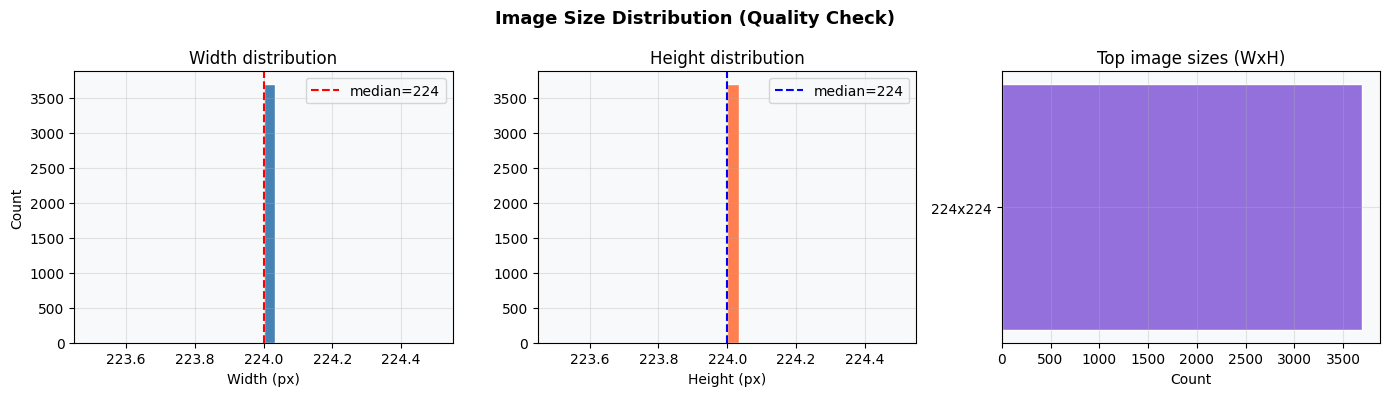

Saved: quality_check.png


In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Image Size Distribution (Quality Check)', fontsize=13, fontweight='bold')

axes[0].hist(widths,  bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Width distribution')
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Count')
axes[0].axvline(np.median(widths), color='red', linestyle='--', label=f'median={int(np.median(widths))}')
axes[0].legend()

axes[1].hist(heights, bins=30, color='coral',     edgecolor='white')
axes[1].set_title('Height distribution')
axes[1].set_xlabel('Height (px)')
axes[1].axvline(np.median(heights), color='blue', linestyle='--', label=f'median={int(np.median(heights))}')
axes[1].legend()

sizes   = list(zip(widths, heights))
unique_sizes = pd.Series([f'{w}x{h}' for w,h in sizes]).value_counts().head(10)
axes[2].barh(unique_sizes.index, unique_sizes.values, color='mediumpurple', edgecolor='white')
axes[2].set_title('Top image sizes (WxH)')
axes[2].set_xlabel('Count')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'quality_check.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: quality_check.png')

## Step 6 — Noise & Blur Check

> We use the **Laplacian variance** method:
> - Apply the Laplacian filter (edge detector) to each image
> - Compute the variance of the result
> - **Low variance → blurry / low detail → possibly bad for feature extraction**
> - Threshold: images with variance < 50 are flagged as potentially blurry

In [ ]:
BLUR_THRESHOLD = 50.0

def compute_blur_score(path):
    """Return Laplacian variance. Lower = blurrier."""
    img = cv2.imread(path)
    if img is None:
        return -1.0
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())


print('Computing blur scores...')
blur_scores = [compute_blur_score(p) for p in tqdm(image_paths, desc='Blur check')]
blur_scores = np.array(blur_scores)

blurry_mask  = blur_scores < BLUR_THRESHOLD
n_blurry     = blurry_mask.sum()

print(f'\nBlur Analysis')
print(f'  Threshold  : {BLUR_THRESHOLD}')
print(f'  Blurry     : {n_blurry} images ({100*n_blurry/len(image_paths):.1f}%)')
print(f'  Sharp      : {len(image_paths)-n_blurry} images')
print(f'  Mean score : {blur_scores[blur_scores>=0].mean():.1f}')

print('\nPer-class blur statistics:')
print(f'{"Class":<20} {"Mean Score":>12} {"Blurry %":>10}')
print('-'*44)
for cls in class_names:
    mask  = np.array(labels) == cls
    scores_cls = blur_scores[mask]
    mean_s     = scores_cls.mean()
    pct_blur   = 100 * (scores_cls < BLUR_THRESHOLD).mean()
    print(f'{cls:<20} {mean_s:>12.1f} {pct_blur:>9.1f}%')

Computing blur scores...


Blur check: 100%|██████████| 3693/3693 [00:26<00:00, 137.21it/s]


Blur Analysis
  Threshold  : 50.0
  Blurry     : 0 images (0.0%)
  Sharp      : 3693 images
  Mean score : 2208.2

Per-class blur statistics:
Class                  Mean Score   Blurry %
--------------------------------------------
biscuits                   6296.0       0.0%
bread                      2217.5       0.0%
butter                     3106.3       0.0%
cheese                     2444.7       0.0%
chips                      2403.8       0.0%
chocolate                  1726.3       0.0%
flour                      2451.3       0.0%
honey                      1987.7       0.0%
jam                        2022.8       0.0%
juice                      1172.2       0.0%
milk                       2266.3       0.0%
nuts                       1931.7       0.0%
oil                        1395.4       0.0%
pasta                      2063.8       0.0%
rice                       2681.9       0.0%
sauce                      2105.0       0.0%
soap                       5714.0       0.0%
sp

/tmp/ipykernel_16440/408276546.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(box_data, labels=class_names, patch_artist=True, notch=False)


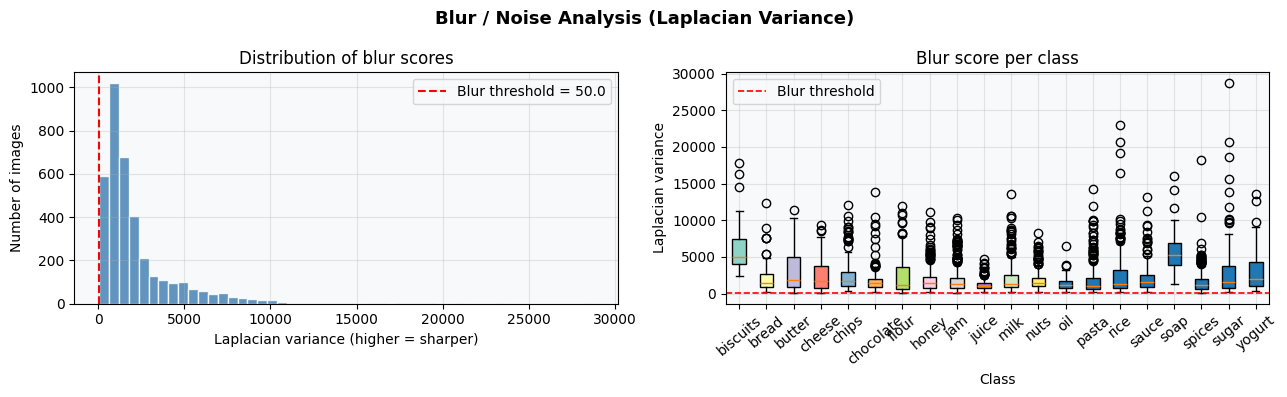

Saved: blur_analysis.png


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Blur / Noise Analysis (Laplacian Variance)', fontsize=13, fontweight='bold')

valid_scores = blur_scores[blur_scores >= 0]
axes[0].hist(valid_scores, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(BLUR_THRESHOLD, color='red', linewidth=1.5, linestyle='--',
                label=f'Blur threshold = {BLUR_THRESHOLD}')
axes[0].set_title('Distribution of blur scores')
axes[0].set_xlabel('Laplacian variance (higher = sharper)')
axes[0].set_ylabel('Number of images')
axes[0].legend()

# Boxplot per class
box_data   = [blur_scores[np.array(labels) == cls] for cls in class_names]
bp = axes[1].boxplot(box_data, labels=class_names, patch_artist=True, notch=False)
colors_bp  = plt.cm.Set3.colors
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
axes[1].axhline(BLUR_THRESHOLD, color='red', linewidth=1.2, linestyle='--', label='Blur threshold')
axes[1].set_title('Blur score per class')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Laplacian variance')
axes[1].tick_params(axis='x', rotation=40)
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'blur_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: blur_analysis.png')

In [ ]:

if n_blurry > 0:
    worst_idx  = np.argsort(blur_scores)[:min(8, n_blurry)]
    n_show     = len(worst_idx)
    fig, axes  = plt.subplots(1, n_show, figsize=(n_show * 2.5, 3))
    if n_show == 1:
        axes = [axes]
    fig.suptitle(f'Most Blurry Images (score < {BLUR_THRESHOLD})', fontsize=12, fontweight='bold')
    for ax, idx in zip(axes, worst_idx):
        img = load_img(image_paths[idx], target_size=(128, 128))
        ax.imshow(img)
        ax.set_title(f'{labels[idx]}\nscore={blur_scores[idx]:.1f}', fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'blurry_samples.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: blurry_samples.png')
else:
    print('No blurry images found — dataset looks clean')

bad_set     = set(bad_idx) | set(np.where(blurry_mask)[0])
clean_idx   = [i for i in range(len(image_paths)) if i not in bad_set]
clean_paths = [image_paths[i] for i in clean_idx]
clean_labels= [labels[i]      for i in clean_idx]
clean_lint  = le.transform(clean_labels)

print(f'\nClean images ready for extraction: {len(clean_paths)} / {len(image_paths)}')

No blurry images found — dataset looks clean

Clean images ready for extraction: 3693 / 3693


### Step 7 — Visualize Dataset Samples & Class Distribution

In [ ]:
N_COLS = 6

fig, axes = plt.subplots(n_classes, N_COLS,
                         figsize=(N_COLS * 1.8, n_classes * 1.8))
fig.suptitle('Sample Images per Class', fontsize=14, fontweight='bold', y=1.01)

for row_idx, cls in enumerate(class_names):
    cls_paths = [p for p, l in zip(clean_paths, clean_labels) if l == cls]
    chosen    = np.random.choice(cls_paths, min(N_COLS, len(cls_paths)), replace=False)
    for col_idx in range(N_COLS):
        ax = axes[row_idx, col_idx]
        if col_idx < len(chosen):
            img = load_img(chosen[col_idx], target_size=(96, 96))
            ax.imshow(img)
        ax.axis('off')
        if col_idx == 0:
            ax.set_ylabel(cls, fontsize=9, rotation=0, labelpad=55, va='center')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_grid.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sample_grid.png')

Output hidden; open in https://colab.research.google.com to view.

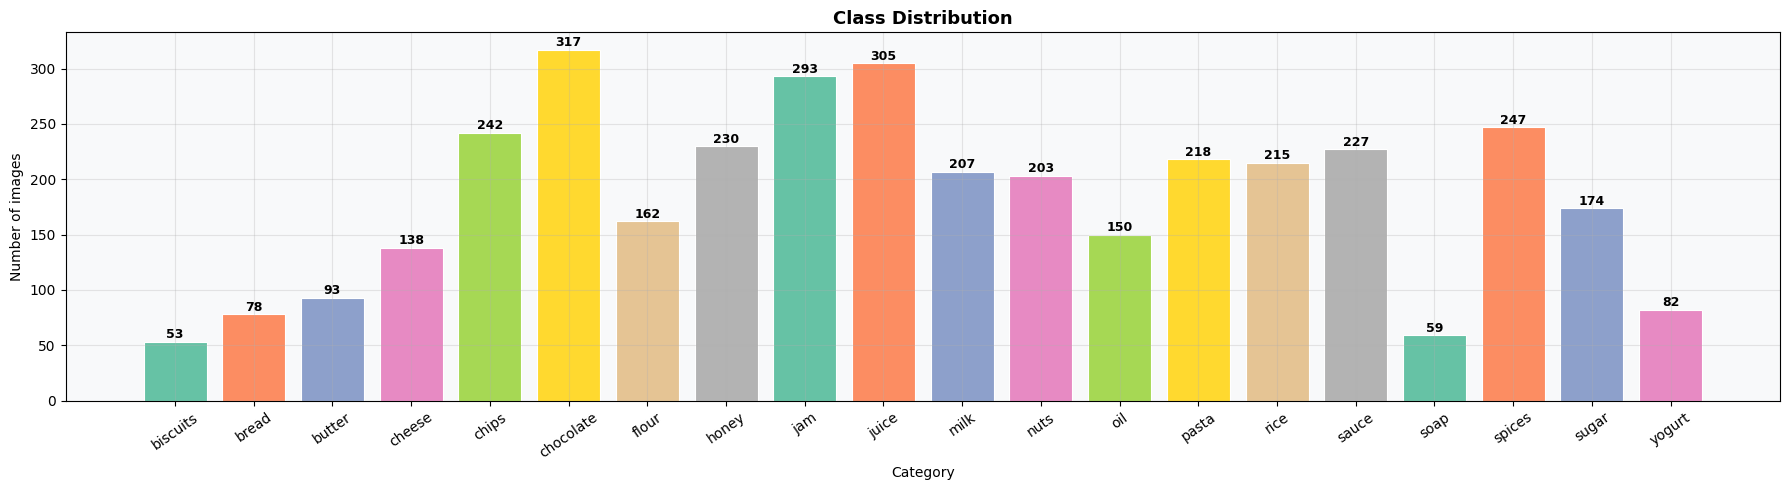

Saved: class_distribution.png


In [ ]:
unique_cls, counts = np.unique(clean_labels, return_counts=True)
palette            = sns.color_palette('Set2', len(unique_cls))

fig, ax = plt.subplots(figsize=(max(7, n_classes * 0.9), 5))
bars    = ax.bar(unique_cls, counts, color=palette, edgecolor='white', linewidth=0.8)

for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(cnt), ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Class Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Number of images')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: class_distribution.png')

## Step 8 — Build ResNet50 Feature Extractor

> **Architecture decision:**
> - Load ResNet50 with ImageNet weights
> - Remove the top FC layer (`include_top=False`)
> - Add `GlobalAveragePooling2D` → collapses `(7,7,2048)` to `(2048,)`
> - **Freeze all** OR **unfreeze last residual block** for fine-tuning

In [ ]:
def build_feature_extractor(image_size=224, freeze_all=True):
    """
    ResNet50 backbone → GlobalAveragePooling → 2048-dim vector.
    """
    base = ResNet50(
        weights      = 'imagenet',
        include_top  = False,
        input_shape  = (image_size, image_size, 3)
    )

    if freeze_all:
        base.trainable = False
        print(f'All {len(base.layers)} ResNet50 layers frozen.')
    else:
        base.trainable = True
        for layer in base.layers:

            if 'conv5_block' not in layer.name:
                layer.trainable = False
        n_trainable = sum(1 for l in base.layers if l.trainable)
        print(f'Unfrozen: {n_trainable} layers (conv5_block only).')

    x     = base.output
    x     = GlobalAveragePooling2D(name='feature_vector')(x)
    model = Model(inputs=base.input, outputs=x, name='ResNet50_FeatureExtractor')
    return model


feature_extractor = build_feature_extractor(IMAGE_SIZE, FREEZE_ALL)

total     = feature_extractor.count_params()
trainable = sum(tf.keras.backend.count_params(w)
                for w in feature_extractor.trainable_weights)

print(f'\nOutput shape     : {feature_extractor.output_shape}')
print(f'Total params     : {total:,}')
print(f'Trainable params : {trainable:,}')
print(f'Frozen params    : {total - trainable:,}')

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Unfrozen: 32 layers (conv5_block only).

Output shape     : (None, 2048)
Total params     : 23,587,712
Trainable params : 14,976,000
Frozen params    : 8,611,712


In [ ]:
layers     = feature_extractor.layers
show_layers = layers[:5] + [None] + layers[-5:]

print(f'\n{"Layer name":<40} {"Output shape":<25} {"Trainable"}')
print('-' * 75)

for layer in show_layers:
    if layer is None:
        print('   ... (175 middle layers) ...')
        continue

    try:
        out = str(layer.output.shape)
    except:
        out = "N/A"

    print(f'{layer.name:<40} {out:<25} {layer.trainable}')


Layer name                               Output shape              Trainable
---------------------------------------------------------------------------
input_layer                              (None, 256, 256, 3)       False
conv1_pad                                (None, 262, 262, 3)       False
conv1_conv                               (None, 128, 128, 64)      False
conv1_bn                                 (None, 128, 128, 64)      False
conv1_relu                               (None, 128, 128, 64)      False
   ... (175 middle layers) ...
conv5_block3_3_conv                      (None, 8, 8, 2048)        True
conv5_block3_3_bn                        (None, 8, 8, 2048)        True
conv5_block3_add                         (None, 8, 8, 2048)        True
conv5_block3_out                         (None, 8, 8, 2048)        True
feature_vector                           (None, 2048)              True


#### FREEZE False

In [ ]:
def build_feature_extractor(image_size=256, freeze_all=False):
    """
    ResNet50 backbone → GlobalAveragePooling → 2048-dim vector.
    """
    base = ResNet50(
        weights      = 'imagenet',
        include_top  = False,
        input_shape  = (image_size, image_size, 3)
    )

    if freeze_all:
        base.trainable = False
        print(f'All {len(base.layers)} ResNet50 layers frozen.')
    else:
        base.trainable = True
        for layer in base.layers:

            if 'conv5_block' not in layer.name:
                layer.trainable = False
        n_trainable = sum(1 for l in base.layers if l.trainable)
        print(f'Unfrozen: {n_trainable} layers (conv5_block only).')

    x     = base.output
    x     = GlobalAveragePooling2D(name='feature_vector')(x)
    model = Model(inputs=base.input, outputs=x, name='ResNet50_FeatureExtractor')
    return model


feature_extractor = build_feature_extractor(IMAGE_SIZE, FREEZE_ALL)

total     = feature_extractor.count_params()
trainable = sum(tf.keras.backend.count_params(w)
                for w in feature_extractor.trainable_weights)

print(f'\nOutput shape     : {feature_extractor.output_shape}')
print(f'Total params     : {total:,}')
print(f'Trainable params : {trainable:,}')
print(f'Frozen params    : {total - trainable:,}')

Unfrozen: 32 layers (conv5_block only).

Output shape     : (None, 2048)
Total params     : 23,587,712
Trainable params : 14,976,000
Frozen params    : 8,611,712


In [ ]:
layers     = feature_extractor.layers
show_layers = layers[:5] + [None] + layers[-5:]

print(f'\n{"Layer name":<40} {"Output shape":<25} {"Trainable"}')
print('-' * 75)

for layer in show_layers:
    if layer is None:
        print('   ... (175 middle layers) ...')
        continue

    try:
        out = str(layer.output.shape)
    except:
        out = "N/A"

    print(f'{layer.name:<40} {out:<25} {layer.trainable}')


Layer name                               Output shape              Trainable
---------------------------------------------------------------------------
input_layer_1                            (None, 256, 256, 3)       False
conv1_pad                                (None, 262, 262, 3)       False
conv1_conv                               (None, 128, 128, 64)      False
conv1_bn                                 (None, 128, 128, 64)      False
conv1_relu                               (None, 128, 128, 64)      False
   ... (175 middle layers) ...
conv5_block3_3_conv                      (None, 8, 8, 2048)        True
conv5_block3_3_bn                        (None, 8, 8, 2048)        True
conv5_block3_add                         (None, 8, 8, 2048)        True
conv5_block3_out                         (None, 8, 8, 2048)        True
feature_vector                           (None, 2048)              True


## Step 9 — Normalization: Why & How

> **Do we need normalization? YES — always.**
>
> Your images on disk: pixel values in `[0, 255]`  
> ResNet50 was trained with: each channel zero-centered around ImageNet means  
> `tf.keras.applications.resnet50.preprocess_input` does it automatically.

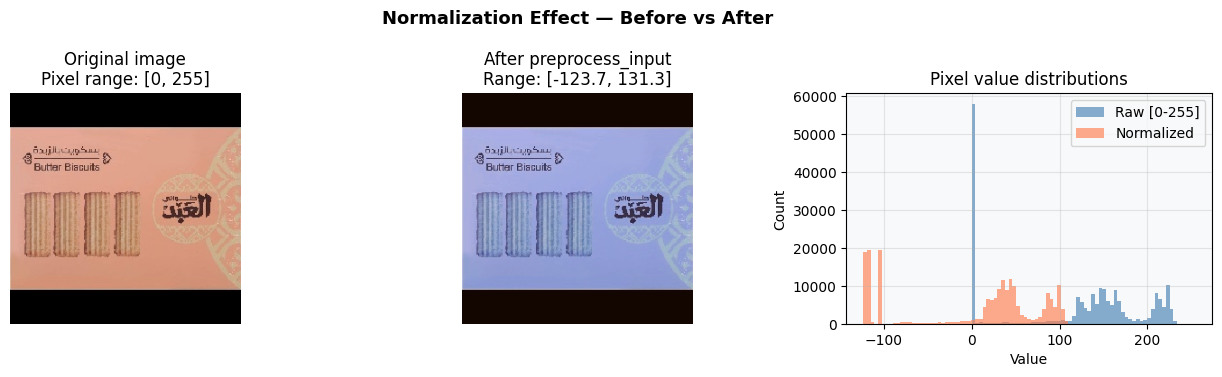

Saved: normalization_demo.png


In [ ]:
sample_path = clean_paths[0]
raw_arr     = img_to_array(load_img(sample_path, target_size=(IMAGE_SIZE, IMAGE_SIZE)))
norm_arr    = preprocess_input(raw_arr.copy())

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
fig.suptitle('Normalization Effect — Before vs After', fontsize=13, fontweight='bold')

axes[0].imshow(raw_arr.astype('uint8'))
axes[0].set_title(f'Original image\nPixel range: [0, 255]')
axes[0].axis('off')

display_norm = (norm_arr - norm_arr.min()) / (norm_arr.max() - norm_arr.min() + 1e-8)
axes[1].imshow(display_norm)
axes[1].set_title(f'After preprocess_input\nRange: [{norm_arr.min():.1f}, {norm_arr.max():.1f}]')
axes[1].axis('off')

axes[2].hist(raw_arr.flatten(),  bins=60, alpha=0.65, color='steelblue', label='Raw [0-255]')
axes[2].hist(norm_arr.flatten(), bins=60, alpha=0.65, color='coral',     label='Normalized')
axes[2].set_title('Pixel value distributions')
axes[2].set_xlabel('Value')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'normalization_demo.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: normalization_demo.png')

### Step 10 — Extract Features

In [ ]:
def load_and_preprocess(path, image_size):
    """Load one image, resize to image_size, apply ImageNet normalization."""
    img = load_img(path, target_size=(image_size, image_size))
    arr = img_to_array(img)
    arr = preprocess_input(arr)
    return arr


def extract_features_batched(model, paths, image_size, batch_size):
    """
    Run all images through the model in mini-batches.
    Returns:
        features : np.ndarray of shape [N, 2048]
    """
    all_feats = []
    n_batches = int(np.ceil(len(paths) / batch_size))

    for i in tqdm(range(n_batches), desc='Extracting features'):
        batch     = paths[i * batch_size : (i + 1) * batch_size]
        batch_arr = np.stack([load_and_preprocess(p, image_size) for p in batch])
        feats     = model.predict(batch_arr, verbose=0)
        all_feats.append(feats)

    return np.vstack(all_feats)


print(f'Extracting features from {len(clean_paths)} images...')
print(f'Image size: {IMAGE_SIZE}x{IMAGE_SIZE} | Batch size: {BATCH_SIZE}\n')

features = extract_features_batched(
    feature_extractor, clean_paths, IMAGE_SIZE, BATCH_SIZE
)

print(f'\n===== Extraction Complete =====')
print(f'Feature matrix shape : {features.shape}')
print(f'Dtype                : {features.dtype}')
print(f'Value range          : [{features.min():.4f}, {features.max():.4f}]')
print(f'Memory usage         : {features.nbytes / 1e6:.1f} MB')

Extracting features from 3693 images...
Image size: 256x256 | Batch size: 32



Extracting features: 100%|██████████| 116/116 [00:55<00:00,  2.08it/s]


===== Extraction Complete =====
Feature matrix shape : (3693, 2048)
Dtype                : float32
Value range          : [0.0000, 23.5671]
Memory usage         : 30.3 MB


#### FREEZE False

In [ ]:
def load_and_preprocess(path, image_size):
    """Load one image, resize to image_size, apply ImageNet normalization."""
    img = load_img(path, target_size=(image_size, image_size))
    arr = img_to_array(img)
    arr = preprocess_input(arr)
    return arr


def extract_features_batched(model, paths, image_size, batch_size):
    """
    Run all images through the model in mini-batches.
    Returns:
        features : np.ndarray of shape [N, 2048]
    """
    all_feats = []
    n_batches = int(np.ceil(len(paths) / batch_size))

    for i in tqdm(range(n_batches), desc='Extracting features'):
        batch     = paths[i * batch_size : (i + 1) * batch_size]
        batch_arr = np.stack([load_and_preprocess(p, image_size) for p in batch])
        feats     = model.predict(batch_arr, verbose=0)
        all_feats.append(feats)

    return np.vstack(all_feats)


print(f'Extracting features from {len(clean_paths)} images...')
print(f'Image size: {IMAGE_SIZE}x{IMAGE_SIZE} | Batch size: {BATCH_SIZE}\n')

features = extract_features_batched(
    feature_extractor, clean_paths, IMAGE_SIZE, BATCH_SIZE
)

print(f'\n===== Extraction Complete =====')
print(f'Feature matrix shape : {features.shape}')
print(f'Dtype                : {features.dtype}')
print(f'Value range          : [{features.min():.4f}, {features.max():.4f}]')
print(f'Memory usage         : {features.nbytes / 1e6:.1f} MB')

Extracting features from 3693 images...
Image size: 256x256 | Batch size: 32



Extracting features: 100%|██████████| 116/116 [00:43<00:00,  2.67it/s]


===== Extraction Complete =====
Feature matrix shape : (3693, 2048)
Dtype                : float32
Value range          : [0.0000, 23.5671]
Memory usage         : 30.3 MB


### Step 11 — Save Everything to Google Drive

In [ ]:

tag = f'img{IMAGE_SIZE}_bs{BATCH_SIZE}_{"frozen" if FREEZE_ALL else "finetune"}'

paths_to_save = {
    'features'    : os.path.join(OUTPUT_DIR, f'features_resnet50_{tag}.npy'),
    'labels_int'  : os.path.join(OUTPUT_DIR, 'labels_int.npy'),
    'labels_str'  : os.path.join(OUTPUT_DIR, 'labels_str.npy'),
    'class_names' : os.path.join(OUTPUT_DIR, 'class_names.npy'),
    'image_paths' : os.path.join(OUTPUT_DIR, 'image_paths.npy'),
}

np.save(paths_to_save['features'],    features)
np.save(paths_to_save['labels_int'],  clean_lint)
np.save(paths_to_save['labels_str'],  np.array(clean_labels))
np.save(paths_to_save['class_names'], class_names)
np.save(paths_to_save['image_paths'], np.array(clean_paths))

print('Files saved to Google Drive:')
for key, path in paths_to_save.items():
    size_mb = os.path.getsize(path) / 1e6
    print(f'  [{key:<12}] {os.path.basename(path):<50} {size_mb:.2f} MB')

print()
print('To load in the Fusion notebook:')
print(f'  features    = np.load("{paths_to_save["features"]}")')
print(f'  labels      = np.load("{paths_to_save["labels_int"]}")')
print(f'  class_names = np.load("{paths_to_save["class_names"]}", allow_pickle=True)')

Files saved to Google Drive:
  [features    ] features_resnet50_img256_bs32_finetune.npy         30.25 MB
  [labels_int  ] labels_int.npy                                     0.03 MB
  [labels_str  ] labels_str.npy                                     0.13 MB
  [class_names ] class_names.npy                                    0.00 MB
  [image_paths ] image_paths.npy                                    2.01 MB

To load in the Fusion notebook:
  features    = np.load("/content/drive/MyDrive/Deep_Learning/features_output/features_resnet50_img256_bs32_finetune.npy")
  labels      = np.load("/content/drive/MyDrive/Deep_Learning/features_output/labels_int.npy")
  class_names = np.load("/content/drive/MyDrive/Deep_Learning/features_output/class_names.npy", allow_pickle=True)


#### FREEZE False

In [ ]:

tag = f'img{IMAGE_SIZE}_bs{BATCH_SIZE}_{"frozen" if FREEZE_ALL else "finetune"}'

paths_to_save = {
    'features'    : os.path.join(OUTPUT_DIR, f'features_resnet50_{tag}.npy'),
    'labels_int'  : os.path.join(OUTPUT_DIR, 'labels_int.npy'),
    'labels_str'  : os.path.join(OUTPUT_DIR, 'labels_str.npy'),
    'class_names' : os.path.join(OUTPUT_DIR, 'class_names.npy'),
    'image_paths' : os.path.join(OUTPUT_DIR, 'image_paths.npy'),
}

np.save(paths_to_save['features'],    features)
np.save(paths_to_save['labels_int'],  clean_lint)
np.save(paths_to_save['labels_str'],  np.array(clean_labels))
np.save(paths_to_save['class_names'], class_names)
np.save(paths_to_save['image_paths'], np.array(clean_paths))

print('Files saved to Google Drive:')
for key, path in paths_to_save.items():
    size_mb = os.path.getsize(path) / 1e6
    print(f'  [{key:<12}] {os.path.basename(path):<50} {size_mb:.2f} MB')

print()
print('To load in the Fusion notebook:')
print(f'  features    = np.load("{paths_to_save["features"]}")')
print(f'  labels      = np.load("{paths_to_save["labels_int"]}")')
print(f'  class_names = np.load("{paths_to_save["class_names"]}", allow_pickle=True)')

Files saved to Google Drive:
  [features    ] features_resnet50_img256_bs32_finetune.npy         30.25 MB
  [labels_int  ] labels_int.npy                                     0.03 MB
  [labels_str  ] labels_str.npy                                     0.13 MB
  [class_names ] class_names.npy                                    0.00 MB
  [image_paths ] image_paths.npy                                    2.01 MB

To load in the Fusion notebook:
  features    = np.load("/content/drive/MyDrive/Deep_Learning/features_output/features_resnet50_img256_bs32_finetune.npy")
  labels      = np.load("/content/drive/MyDrive/Deep_Learning/features_output/labels_int.npy")
  class_names = np.load("/content/drive/MyDrive/Deep_Learning/features_output/class_names.npy", allow_pickle=True)


## Step 12 — Visualization: t-SNE

> t-SNE reduces 2048 dimensions → 2D so we can **see** whether the features cluster by class.
> Well-separated clusters = good features for the Fusion module.

Subsampled to 1500 points for t-SNE.
Running t-SNE (30-120 seconds)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE done.


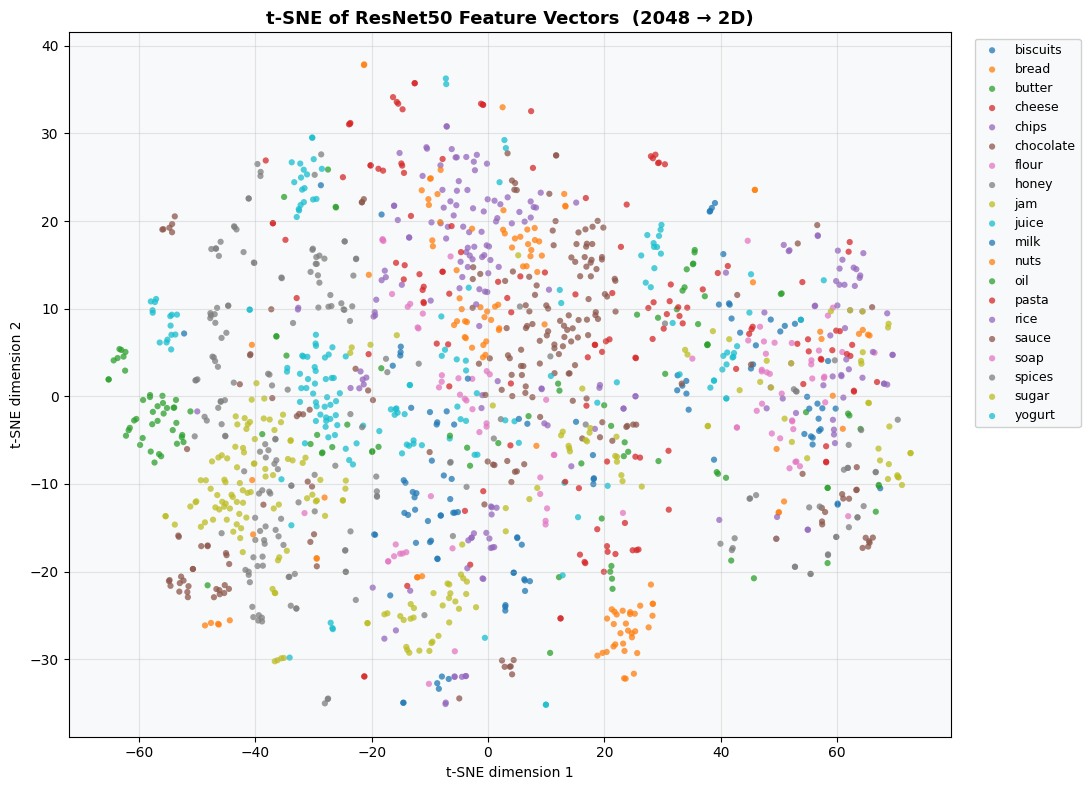

Saved: tsne_img256_bs32_finetune.png

Interpretation: tight, well-separated clusters → features are discriminative ✓


In [ ]:
MAX_TSNE = 1500

if len(features) > MAX_TSNE:
    idx      = np.random.choice(len(features), MAX_TSNE, replace=False)
    f_sub    = features[idx]
    l_sub    = clean_lint[idx]
    lb_sub   = np.array(clean_labels)[idx]
    print(f'Subsampled to {MAX_TSNE} points for t-SNE.')
else:
    f_sub    = features
    l_sub    = clean_lint
    lb_sub   = np.array(clean_labels)

print('Running t-SNE (30-120 seconds)...')
tsne    = TSNE(n_components=2, perplexity=30, n_iter=1000,
               learning_rate='auto', init='pca', random_state=42)
feat_2d = tsne.fit_transform(f_sub)
print('t-SNE done.')


fig, ax = plt.subplots(figsize=(11, 8))
palette = sns.color_palette('tab10', n_classes)

for i, cls in enumerate(class_names):
    mask = l_sub == i
    ax.scatter(feat_2d[mask, 0], feat_2d[mask, 1],
               c=[palette[i]], label=cls,
               alpha=0.75, s=20, edgecolors='none')

ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9, framealpha=0.9)
ax.set_title('t-SNE of ResNet50 Feature Vectors  (2048 → 2D)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE dimension 1')
ax.set_ylabel('t-SNE dimension 2')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'tsne_{tag}.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: tsne_{tag}.png')
print()
print('Interpretation: tight, well-separated clusters → features are discriminative ✓')


## Step 13 — Visualization: Activation Heatmaps

> We look at the **mean activation of the last conv layer** overlaid on the image.  
> This shows *where* in the image ResNet50 is paying attention.

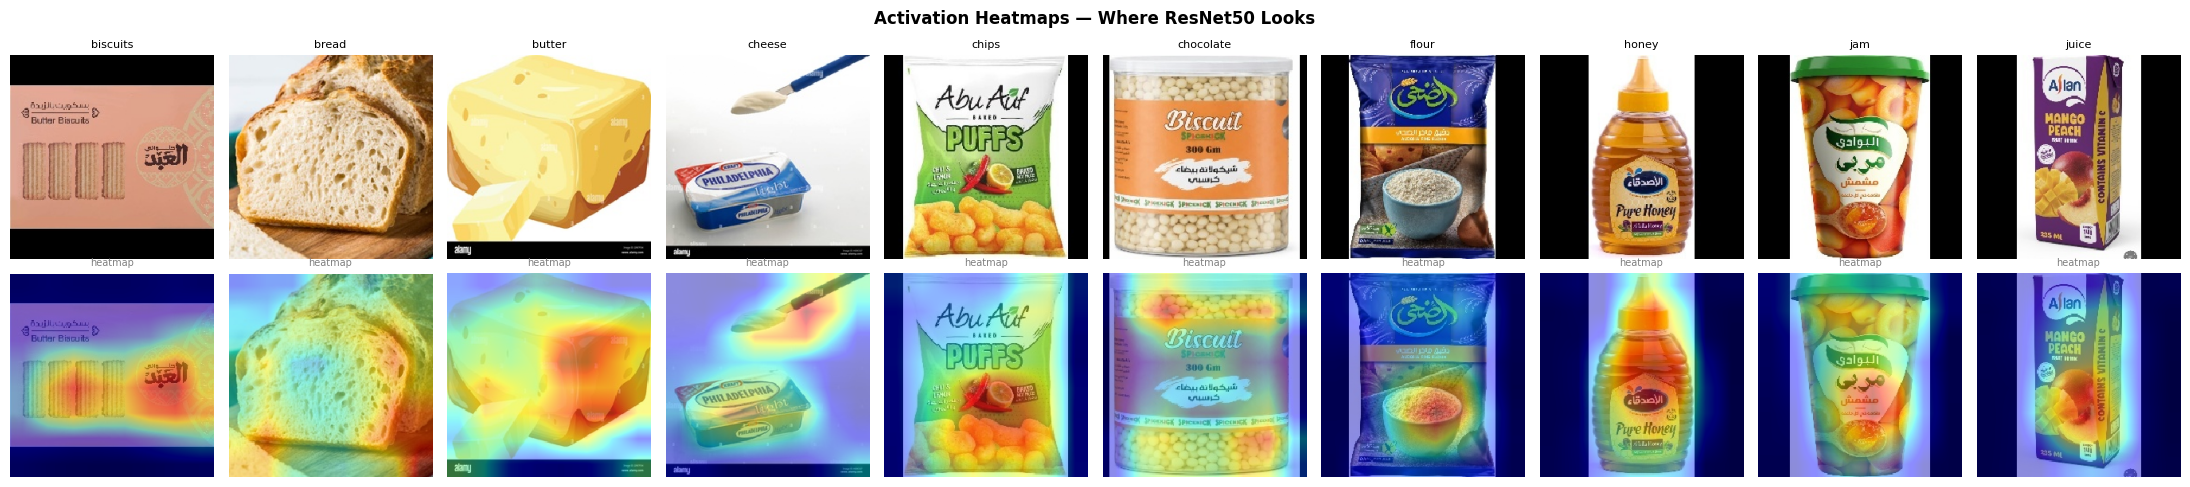

Saved: activation_heatmaps.png


In [ ]:
LAST_CONV = 'conv5_block3_out'

activation_model = Model(
    inputs  = feature_extractor.input,
    outputs = feature_extractor.get_layer(LAST_CONV).output
)


def get_heatmap(path, image_size):
    """Return normalized (7,7) activation heatmap for one image."""
    arr  = load_and_preprocess(path, image_size)
    acts = activation_model.predict(arr[np.newaxis], verbose=0)
    hm   = np.mean(acts[0], axis=-1)
    hm   = np.maximum(hm, 0)
    hm  /= hm.max() + 1e-8
    return hm


N_SHOW   = min(n_classes, 10)
cls_show = class_names[:N_SHOW]

fig, axes = plt.subplots(2, N_SHOW, figsize=(N_SHOW * 2.2, 5))
fig.suptitle('Activation Heatmaps — Where ResNet50 Looks', fontsize=12, fontweight='bold')

for col, cls in enumerate(cls_show):
    cls_paths = [p for p, l in zip(clean_paths, clean_labels) if l == cls]
    path      = cls_paths[0]

    raw = np.array(load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))).astype('float32') / 255.0
    hm  = get_heatmap(path, IMAGE_SIZE)

    hm_resized = tf.image.resize(hm[:, :, np.newaxis],
                                  [IMAGE_SIZE, IMAGE_SIZE]).numpy()[:, :, 0]
    overlay   = raw * 0.55 + plt.cm.jet(hm_resized)[:, :, :3] * 0.45
    overlay   = np.clip(overlay, 0, 1)

    axes[0, col].imshow(raw)
    axes[0, col].set_title(cls, fontsize=8)
    axes[0, col].axis('off')

    axes[1, col].imshow(overlay)
    axes[1, col].set_title('heatmap', fontsize=7, color='gray')
    axes[1, col].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'activation_heatmaps.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: activation_heatmaps.png')

### Step 14 — Visualization: Feature Vector Statistics

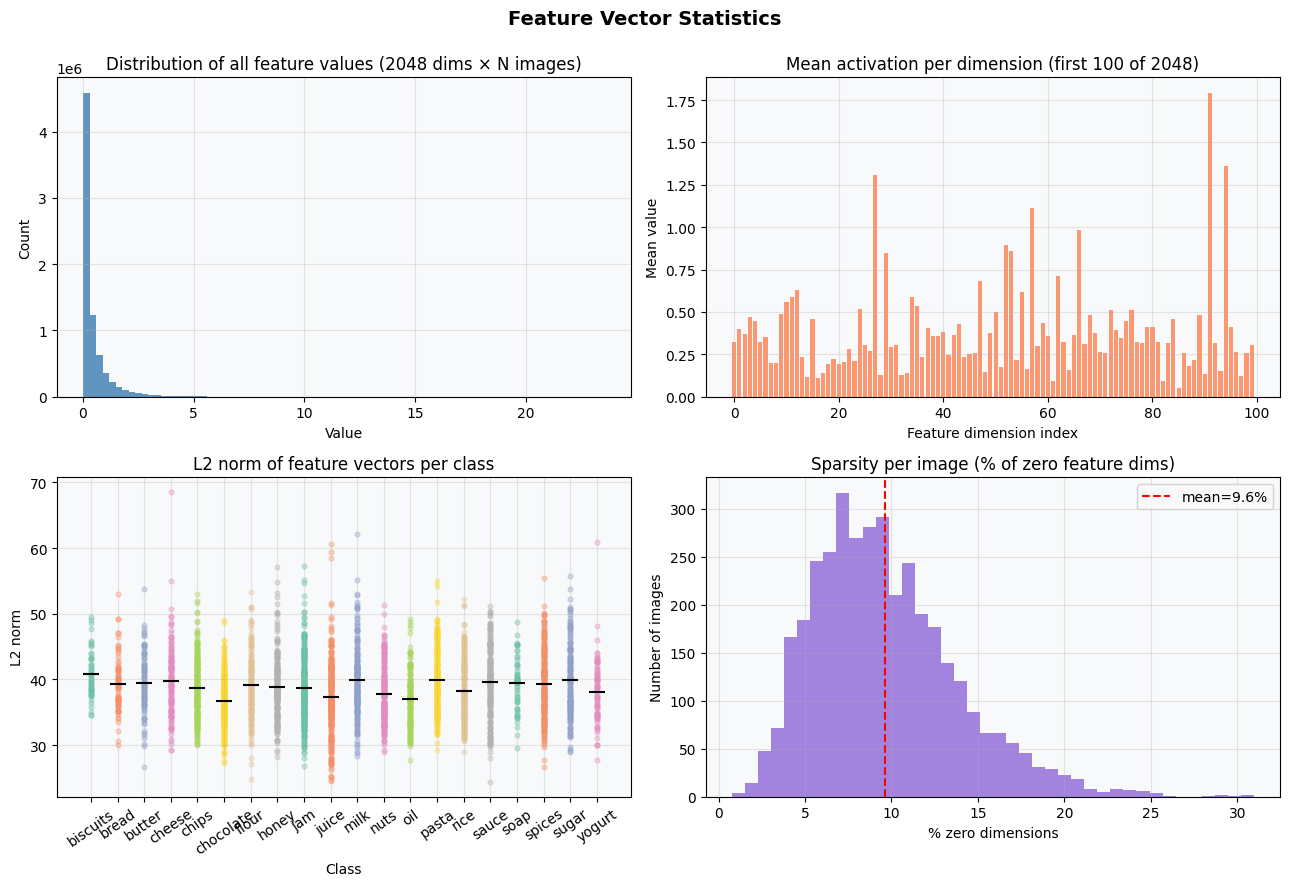

Saved: feature_stats_img256_bs32_finetune.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Feature Vector Statistics', fontsize=14, fontweight='bold')

axes[0, 0].hist(features.flatten(), bins=80, color='steelblue', edgecolor='none', alpha=0.85)
axes[0, 0].set_title('Distribution of all feature values (2048 dims × N images)')
axes[0, 0].set_xlabel('Value')
axes[0, 0].set_ylabel('Count')

dim_means = features[:, :100].mean(axis=0)
axes[0, 1].bar(range(100), dim_means, color='coral', alpha=0.8)
axes[0, 1].set_title('Mean activation per dimension (first 100 of 2048)')
axes[0, 1].set_xlabel('Feature dimension index')
axes[0, 1].set_ylabel('Mean value')

norms   = np.linalg.norm(features, axis=1)
for i, cls in enumerate(class_names):
    mask = clean_lint == i
    axes[1, 0].scatter(
        [cls] * mask.sum(), norms[mask],
        alpha=0.35, s=12,
        color=sns.color_palette('Set2', n_classes)[i]
    )
    axes[1, 0].hlines(
        norms[mask].mean(), i - 0.3, i + 0.3,
        colors='black', linewidths=1.5
    )
axes[1, 0].set_title('L2 norm of feature vectors per class')
axes[1, 0].set_xlabel('Class')
axes[1, 0].set_ylabel('L2 norm')
axes[1, 0].tick_params(axis='x', rotation=35)

sparsity = (features == 0).mean(axis=1) * 100
axes[1, 1].hist(sparsity, bins=40, color='mediumpurple', edgecolor='none', alpha=0.85)
axes[1, 1].set_title('Sparsity per image (% of zero feature dims)')
axes[1, 1].set_xlabel('% zero dimensions')
axes[1, 1].set_ylabel('Number of images')
axes[1, 1].axvline(sparsity.mean(), color='red', linestyle='--',
                   label=f'mean={sparsity.mean():.1f}%')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'feature_stats_{tag}.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: feature_stats_{tag}.png')


##  Step 15 — Experiment Comparison

> Run the notebook **twice** with different settings:
> - Run 1: `IMAGE_SIZE=224, FREEZE_ALL=True`
> - Run 2: `IMAGE_SIZE=256, FREEZE_ALL=False`
>
> Then run this cell to compare automatically.

In [ ]:
npy_files = sorted(Path(OUTPUT_DIR).glob('features_resnet50_*.npy'))

if len(npy_files) < 2:
    print('Only one experiment found.')
    print('Run the notebook again with different IMAGE_SIZE or FREEZE_ALL to compare.')
else:
    labs = np.load(paths_to_save['labels_int'])
    results = []

    for f in npy_files:
        feats   = np.load(str(f))
        normed  = feats / (np.linalg.norm(feats, axis=1, keepdims=True) + 1e-8)

        intra, inter = [], []
        rng   = np.random.default_rng(0)
        pairs = rng.choice(len(labs), (2000, 2), replace=True)
        for a, b in pairs:
            sim = float(normed[a] @ normed[b])
            (intra if labs[a] == labs[b] else inter).append(sim)

        sep = np.mean(intra) - np.mean(inter)
        results.append({
            'experiment'      : f.stem.replace('features_resnet50_', ''),
            'n_images'        : feats.shape[0],
            'feature_dim'     : feats.shape[1],
            'intra_sim'       : round(float(np.mean(intra)), 4),
            'inter_sim'       : round(float(np.mean(inter)), 4),
            'separation'      : round(float(sep), 4),
        })

    df_cmp = pd.DataFrame(results).sort_values('separation', ascending=False)
    print(df_cmp.to_string(index=False))
    print()
    print(f'Best experiment: {df_cmp.iloc[0]["experiment"]}')
    print('(Highest separation = features most discriminative between classes)')

          experiment  n_images  feature_dim  intra_sim  inter_sim  separation
  img224_bs32_frozen      3693         2048     0.5576     0.4727      0.0848
img256_bs32_finetune      3693         2048     0.5687     0.4870      0.0817

Best experiment: img224_bs32_frozen
(Highest separation = features most discriminative between classes)


---
## Step 16 — Final Summary

| Item | Detail |
|------|--------|
| Model | ResNet50 pretrained on ImageNet |
| FC layer | Removed (`include_top=False`) |
| Pooling | GlobalAveragePooling2D |
| Output vector | **2048 dimensions** per image |
| Normalization | `preprocess_input` — always required |
| Quality checks | Size, channels, blur (Laplacian variance) |
| Saved files | `features_resnet50_*.npy`, `labels_int.npy`, `class_names.npy` |
| Visualizations | Sample grid, class dist, quality check, blur analysis, normalization demo, t-SNE, activation heatmaps, feature stats |

---

### What the Fusion Module Needs
```python

image_features = np.load('.../features_resnet50_img224_bs32_frozen.npy')  
text_features  = np.load('.../features_bert.npy')                          
labels         = np.load('.../labels_int.npy')                             


fused = np.concatenate([text_features, image_features], axis=1)            
```

In [ ]:
import numpy as np
import os

OUTPUT_DIR = '/content/drive/MyDrive/Deep_Learning/features_output'

print('='*55)
print('FILES ON DRIVE:')
print('='*55)
for f in os.listdir(OUTPUT_DIR):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / 1e6
    print(f'  {f:<55} {size:.2f} MB')

print()
print('='*55)
print('LOADING FEATURES:')
print('='*55)
image_features = np.load(f'{OUTPUT_DIR}/features_resnet50_img224_bs32_frozen.npy')
labels_int     = np.load(f'{OUTPUT_DIR}/labels_int.npy')
labels_str     = np.load(f'{OUTPUT_DIR}/labels_str.npy', allow_pickle=True)
class_names    = np.load(f'{OUTPUT_DIR}/class_names.npy', allow_pickle=True)

print(f'  image_features shape : {image_features.shape}')
print(f'  labels shape         : {labels_int.shape}')
print(f'  number of classes    : {len(class_names)}')
print(f'  class names          : {class_names}')

print()
print('='*55)
print('SAMPLE (first 5 images):')
print('='*55)
for i in range(5):
    vec_preview = image_features[i, :6]
    print(f'  Image {i+1}:')
    print(f'    Class      : {labels_str[i]}')
    print(f'    Label int  : {labels_int[i]}')
    print(f'    Vector[:6] : {np.round(vec_preview, 4)}')
    print(f'    Vector norm: {np.linalg.norm(image_features[i]):.4f}')
    print()

print('='*55)
print('FUSION SIMULATION:')
print('='*55)
N = image_features.shape[0]
text_features_mock = np.random.rand(N, 768).astype('float32')
fused = np.concatenate([text_features_mock, image_features], axis=1)
print(f'  text_features  : {text_features_mock.shape}  (mock until BERT is ready)')
print(f'  image_features : {image_features.shape}')
print(f'  fused          : {fused.shape}')

print()
print('='*55)
if image_features.shape == (N, 2048) and fused.shape == (N, 2816):
    print('ALL CHECKS PASSED — Ready for Fusion Team!')
else:
    print('SOMETHING IS WRONG — Please review steps.')
print('='*55)